# 선행지표를 찾는 3가지 방법

후행지표(예: **D7 잔존**)는 결과가 나오기까지 시간이 걸려 즉각적인 진단이 어렵습니다.
그래서 후행지표를 미리 가늠할 **선행지표(leading indicator)** 를 함께 찾아 관리합니다.

이 노트북은 **하나의 신규 유저 이벤트 로그**(`data/event_log.csv`)를 가지고, "신규 유저의
D7 잔존을 끌어올릴 선행지표"를 **세 가지 방법**으로 찾아봅니다. *같은 데이터·같은 타깃,
세 가지 렌즈*입니다.

1. **EDA 비교** — 잔존/비잔존 코호트의 D0~D1 행동을 발생 비중·평균 횟수로 비교
2. **SHAP Value** — 잔존을 예측하는 모델을 만들고 각 행동의 기여도를 분해
3. **Sankey Diagram** — 설치 직후 행동 흐름을 그리고, 어느 갈림길에서 잔존이 갈리는지 색으로 확인

## 0. 실습용 데이터 준비

아래 셀이 의존성을 설치합니다. 데이터가 없다면 먼저 터미널에서 `python generate_data.py` 를 실행해 `data/event_log.csv` 를 만들어 주세요.

이 챕터는 lightgbm·shap·optuna·plotly 등 의존성이 가장 무거운 챕터라, 첫 실행이면 설치
시간까지 포함해 조금 더 걸릴 수 있습니다.

In [1]:
# 의존성 설치 (이미 설치돼 있으면 빠르게 넘어갑니다)
%pip install -q -r requirements.txt


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# --- 책 공통 차트 스타일 (팔레트·그리드·spine 통일) ---
PALETTE = ["#1f9d78", "#3b4556", "#d97706", "#6b7380"]  # green, slate, amber, muted
plt.rcParams.update({
    "axes.prop_cycle": plt.cycler(color=PALETTE),
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y", "grid.alpha": 0.3,
    "figure.dpi": 150, "legend.frameon": False,
})

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

# DuckDB 인메모리 연결 하나를 만들어 노트북 전체에서 재사용합니다.
con = duckdb.connect()
con.execute(
    "CREATE OR REPLACE TABLE event_log AS "
    "SELECT * FROM read_csv_auto('data/event_log.csv')"
)
con.query(
    "SELECT COUNT(*) AS event_rows, COUNT(DISTINCT user_id) AS users FROM event_log"
).to_df()

,event_rows,users
0,136391,12000


### D7 잔존 라벨링

설치(D0) 유저를 모수로 두고, 설치 후 **7일째 활동이 있으면 D7 잔존(=1)** 으로 라벨링합니다.

먼저 설치 시점과 D7 잔존 라벨을 뷰로 등록해 둡니다. 세 실습이 모두 같은 라벨을 쓰므로 한 번만 정의합니다.

실제 로그를 사용할 때는 설치 후 7일이 아직 지나지 않은 유저를 모수에서 제외해야 합니다. 실습의
라벨링 쿼리는 D7 활동이 없으면 모두 비잔존으로 처리하기 때문에, 관측 기간이 끝나지 않은 최근
설치 유저가 포함된다면 결과가 왜곡될 수 있습니다.
세 실습이 모두 이 뷰를 쓰므로 여기서 한 번만 정의합니다.


In [3]:
con.execute("""
-- 설치(D0) 시점: 유저별 첫 system_app_install
CREATE OR REPLACE VIEW installs AS
  SELECT user_id, MIN(event_timestamp) AS install_ts, MIN(event_date) AS install_date
  FROM event_log WHERE event_name = 'system_app_install' GROUP BY 1;

-- D7 잔존 라벨: 설치 7일째에 활동이 있으면 1. 실습 1·2·3 이 모두 이 뷰를 쓴다
CREATE OR REPLACE VIEW d7_label AS
  SELECT i.user_id, i.install_ts, i.install_date,
         MAX(CASE WHEN date_diff('day', i.install_date, e.event_date) = 7 THEN 1 ELSE 0 END) AS d7_retention_flag
  FROM installs AS i LEFT JOIN event_log AS e ON i.user_id = e.user_id
  GROUP BY 1, 2, 3
""")
labels = con.query("SELECT * FROM d7_label").to_df()
(labels["d7_retention_flag"].value_counts(normalize=True)
    .rename(index={0: "비잔존(0)", 1: "잔존(1)"}).mul(100).round(1).rename("share(%)").to_frame())

,share(%)
d7_retention_flag,
비잔존(0),60.30
잔존(1),39.70


---
## 실습 1. EDA로 선행지표 후보 찾기

가장 먼저 할 일은 **탐색**입니다. 미리 정해둔 가설 없이 모든 이벤트를 펼쳐 놓고, 잔존 유저와
비잔존 유저가 **무엇을 다르게 하는지** 살펴봅니다. 명확한 인과는 아니지만, 두 코호트의 행동
차이에서 선행지표 후보를 얻을 수 있습니다.

### D0~D1 행동 집계 — 코호트 비교

준비 절에서 붙인 라벨 위에, **D0~D1 구간**의 행동을 이벤트별로 집계해 두 코호트를 비교합니다.
- `share` : 그 행동을 한 번이라도 한 유저 비중 (코호트 내 %)
- `avg_event_count` : 그 행동을 한 유저들의 평균 발생 횟수

`share_diff`(잔존 − 비잔존) 내림차순으로 정렬하면, 잔존 유저가 **특별히 많이 하는 행동**이
위로 올라옵니다. (쿼리는 `sql/eda_leading_indicator.sql` 에도 있습니다.)

이 라벨 위에 D0~D1 구간의 행동을 코호트별로 집계해, 행동마다 수행 비중과 평균 횟수를 나란히 놓습니다.

In [4]:
eda_query = """
WITH log_data AS (   -- raw 로그를 (유저, 이벤트, 화면, 일자) 단위 발생 횟수로 집계
    SELECT event_date, event_name, screen_name, user_id,
           SUM(event_count) AS event_count, MAX(description) AS description
    FROM event_log
    GROUP BY 1, 2, 3, 4
),
event_stat AS (      -- 코호트(잔존/비잔존)별 D0~D1 구간 행동: 한 유저 수와 평균 횟수
    SELECT r.d7_retention_flag, l.event_name, l.screen_name,
           COUNT(DISTINCT r.user_id) AS user_cnt, AVG(l.event_count) AS avg_event_count
    FROM d7_label AS r
    LEFT JOIN log_data AS l
      ON r.user_id = l.user_id AND l.event_date >= r.install_date
     AND date_diff('day', r.install_date, l.event_date) <= 1
    GROUP BY 1, 2, 3
),
population AS (SELECT d7_retention_flag, COUNT(*) AS total_user_cnt FROM d7_label GROUP BY 1),
cohort_info AS (     -- 코호트 안에서 그 행동을 한 유저 비중(%)
    SELECT e.*, (e.user_cnt * 1.0 / p.total_user_cnt) * 100 AS share
    FROM event_stat AS e LEFT JOIN population AS p USING (d7_retention_flag)
)
SELECT event_name, screen_name,
       MAX(CASE WHEN d7_retention_flag = 0 THEN share           END) AS d7_ret0_share,
       MAX(CASE WHEN d7_retention_flag = 0 THEN avg_event_count END) AS d7_ret0_avg_cnt,
       MAX(CASE WHEN d7_retention_flag = 1 THEN share           END) AS d7_ret1_share,
       MAX(CASE WHEN d7_retention_flag = 1 THEN avg_event_count END) AS d7_ret1_avg_cnt,
       d7_ret1_share - d7_ret0_share     AS share_diff,
       d7_ret1_avg_cnt - d7_ret0_avg_cnt AS event_cnt_diff
FROM cohort_info
WHERE event_name IS NOT NULL
GROUP BY 1, 2
HAVING d7_ret1_share >= 10 OR d7_ret0_share >= 10
ORDER BY share_diff DESC
"""
eda = con.query(eda_query).to_df()
eda.round(1)

,event_name,screen_name,d7_ret0_share,d7_ret0_avg_cnt,d7_ret1_share,d7_ret1_avg_cnt,share_diff,event_cnt_diff
0,tap_like_button,content_detail,28.10,1.50,74.90,2.30,46.80,0.80
1,page_view_content_detail,content_detail,58.80,3.80,100.00,4.80,41.20,0.90
2,tap_share_button,content_detail,16.80,1.20,51.10,1.60,34.30,0.40
3,tap_tutorial_complete,onboarding,46.00,1.00,77.80,1.00,31.70,0.00
4,tap_search_button,search,6.70,3.70,30.60,5.70,23.90,1.90
5,system_push_permission_granted,permission,41.10,1.00,62.90,1.00,21.90,0.00
6,page_view_home,home,100.00,1.00,100.00,1.00,0.00,0.00
7,page_view_onboarding_step,onboarding,100.00,1.00,100.00,1.00,0.00,0.00
8,system_app_install,app,100.00,1.00,100.00,1.00,0.00,0.00
9,page_view_profile,profile,27.40,1.00,5.80,1.00,-21.50,0.00


### 해석·시각화

표만으로도 이야기가 보입니다. 잔존 유저는 **튜토리얼 완료·콘텐츠 조회·좋아요**를 훨씬 높은
비중으로 합니다. 반대로 **에러 팝업·내정보/설정** 비중은 비잔존 쪽이 높습니다. 막대그래프로
잔존 vs 비잔존 share를 나란히 보면 격차가 한눈에 들어옵니다.

표를 그림으로 옮겨 보면 차이가 한눈에 들어옵니다. 본문 2절의 그림1이 이 코드의 결과입니다.

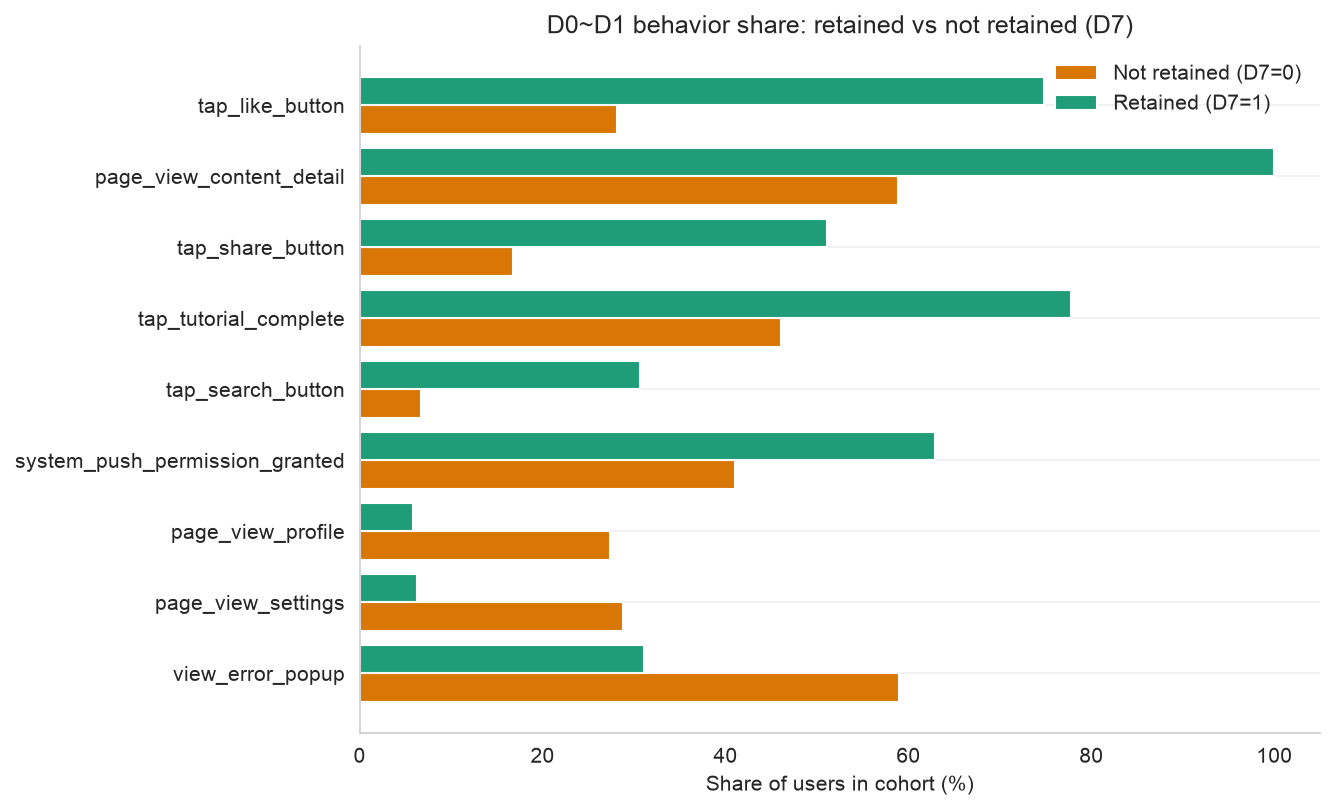

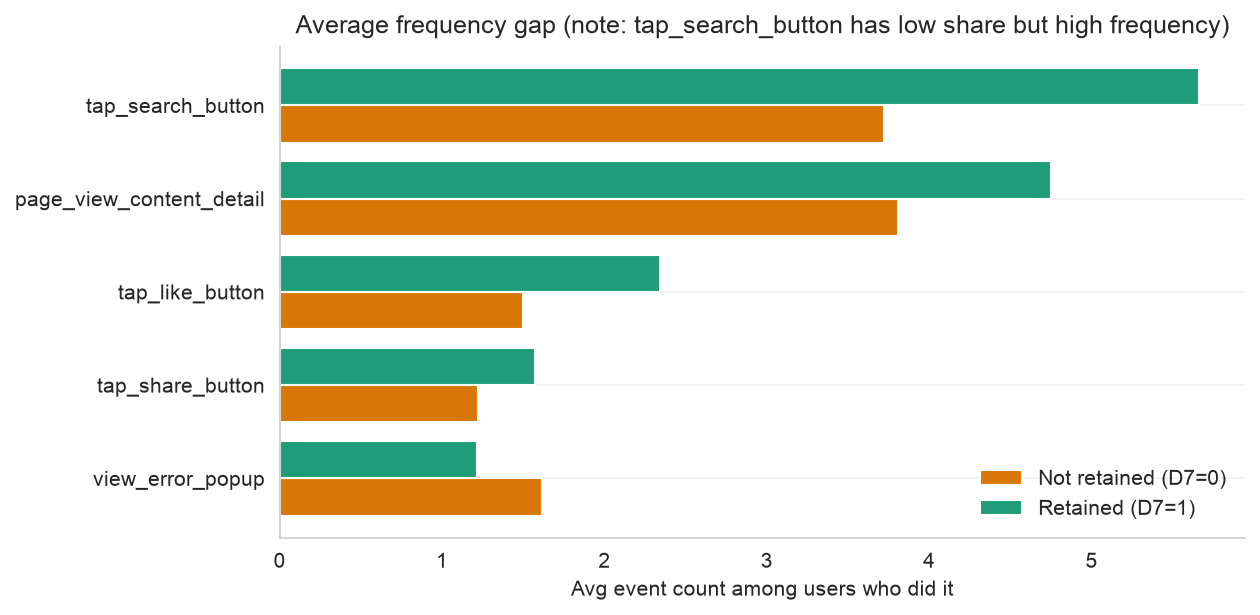

In [5]:
def gap_chart(frame, col0, col1, xlabel, title, figsize):
    # 잔존(초록) vs 비잔존(빨강) 코호트를 행동별로 나란히 비교하는 가로 막대
    y = np.arange(len(frame))
    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(y - 0.2, frame[col0], height=0.4, label="Not retained (D7=0)", color="#d97706")
    ax.barh(y + 0.2, frame[col1], height=0.4, label="Retained (D7=1)", color="#1f9d78")
    ax.set_yticks(y); ax.set_yticklabels(frame["event_name"])
    ax.set_xlabel(xlabel); ax.set_title(title); ax.legend()
    plt.tight_layout(); plt.show()

# (1) 수행 비중 차이가 큰 행동 9개
top9 = (eda.assign(abs_diff=eda["share_diff"].abs())
           .sort_values("abs_diff", ascending=False).head(9).sort_values("share_diff"))
gap_chart(top9, "d7_ret0_share", "d7_ret1_share", "Share of users in cohort (%)",
          "D0~D1 behavior share: retained vs not retained (D7)", (9, 5.5))

# (2) 평균 횟수 차이 — tap_search_button 는 비중은 낮지만 하는 유저는 자주 한다
spot = eda[eda["event_name"].isin(["page_view_content_detail", "tap_like_button", "tap_search_button",
                                   "tap_share_button", "view_error_popup"])].sort_values("d7_ret1_avg_cnt")
gap_chart(spot, "d7_ret0_avg_cnt", "d7_ret1_avg_cnt", "Avg event count among users who did it",
          "Average frequency gap (note: tap_search_button has low share but high frequency)", (8.5, 4.2))

`tap_search_button`(검색)는 결이 다른 신호입니다. 수행 **비중(share)** 은 낮지만, 하는 유저는
**여러 번** 합니다 — 즉 평균 발생 횟수(`avg_event_count`)는 잔존 유저가 월등히 높습니다.
비중만 봐서는 놓치기 쉬운, 횟수로 드러나는 선행지표 후보입니다.

쿼리 구조 자체는 어렵지 않습니다. 한 번 이해해 두면 요소별로 변형해 더 넓게 탐색할 수 있습니다.
예를 들어 라벨을 D7 잔존 대신 D1 잔존으로 두고 D0 행동만 비교할 수도 있고, 잔존을 구매 전환으로
바꿔 서비스에 진입한 유저의 행동을 비교할 수도 있습니다.

---
## 실습 2. SHAP Value로 기여도 분해하기

EDA가 후보를 던져 줬다면, 이제 **여러 행동을 동시에 놓고** 각 행동이 잔존 예측에 얼마나, 어떤
방향으로 기여하는지 정량화할 차례입니다. D7 잔존을 예측하는 **LGBM** 모델을 만들고,
**SHAP Value** 로 기여도를 분해합니다. 모델 자체의 정확도를 끌어올리는 게 목적이 아니라,
"어떤 행동이 예측을 끌어올리는가"를 읽기 위한 도구로 모델을 씁니다.

### 2.1. 피처 행렬·라벨 준비

설치 첫 세션(D0)의 행동을 유저 단위 피처로 집계하고 D7 잔존을 라벨로 붙입니다.
(쿼리는 `sql/feature_matrix.sql` 에도 있습니다.)

여기서 피처 집계 구간을 설치 당일(D0) 세션으로만 자르는 데는 이유가 있습니다. 라벨로 쓰는 D7
잔존 이후 행동이 피처에 섞이면 모델이 '미래를 보고' 예측하는 셈이 되기 때문인데요. 이런 데이터
누수가 생기면 결과 전체를 믿을 수 없게 됩니다.

In [6]:
fm_query = """
WITH d0_session AS (   -- 설치 당일(D0) 세션 이벤트만
    SELECT e.user_id, e.event_name, e.event_count, e.event_timestamp
    FROM installs AS i
    JOIN event_log AS e ON i.user_id = e.user_id AND date_diff('day', i.install_date, e.event_date) = 0
),
feat AS (
    SELECT user_id,
           MAX(CASE WHEN event_name = 'tap_tutorial_complete' THEN 1 ELSE 0 END) AS tap_tutorial_complete,
           MAX(CASE WHEN event_name = 'system_push_permission_granted'        THEN 1 ELSE 0 END) AS system_push_permission_granted,
           COUNT(*) FILTER (WHERE event_name = 'page_view_content_detail')      AS page_view_content_detail,
           COUNT(*) FILTER (WHERE event_name = 'tap_like_button')      AS tap_like_button,
           COUNT(*) FILTER (WHERE event_name = 'tap_search_button')       AS tap_search_button,
           COUNT(*) FILTER (WHERE event_name = 'tap_share_button')     AS tap_share_button,
           COUNT(*) FILTER (WHERE event_name = 'page_view_profile') AS page_view_profile,
           COUNT(*) FILTER (WHERE event_name = 'page_view_settings')     AS page_view_settings,
           COUNT(*) FILTER (WHERE event_name = 'view_error_popup')       AS view_error_popup,
           -- 설치 세션 길이(초): 첫 이벤트 ~ 마지막 이벤트
           date_diff('second', MIN(event_timestamp), MAX(event_timestamp)) AS session_duration_sec
    FROM d0_session
    GROUP BY 1
)
SELECT l.d7_retention_flag, f.*
FROM d7_label AS l JOIN feat AS f USING (user_id)
ORDER BY user_id   -- 행 순서를 고정해야 train/test 분할(따라서 정확도)이 실행마다 같다
"""
fm = con.query(fm_query).to_df()
y = fm["d7_retention_flag"]
X = fm.drop(columns=["d7_retention_flag", "user_id"])   # 식별자·라벨은 피처에서 제외

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=314, stratify=y)
X.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
tap_tutorial_complete,"12,000.00",0.59,0.49,0.00,0.00,1.00,1.00,1.00
system_push_permission_granted,"12,000.00",0.50,0.50,0.00,0.00,0.00,1.00,1.00
page_view_content_detail,"12,000.00",1.59,1.70,0.00,0.00,1.00,3.00,8.00
tap_like_button,"12,000.00",0.95,1.34,0.00,0.00,0.00,2.00,8.00
tap_search_button,"12,000.00",0.56,1.44,0.00,0.00,0.00,0.00,6.00
tap_share_button,"12,000.00",0.44,0.79,0.00,0.00,0.00,1.00,6.00
page_view_profile,"12,000.00",0.19,0.39,0.00,0.00,0.00,0.00,1.00
page_view_settings,"12,000.00",0.20,0.40,0.00,0.00,0.00,0.00,1.00
view_error_popup,"12,000.00",0.73,0.91,0.00,0.00,0.00,1.00,3.00
session_duration_sec,"12,000.00",119.36,82.55,9.00,56.00,99.00,162.00,541.00


### 2.2. 베이스라인 LGBM 학습·평가

먼저 고정 하이퍼파라미터로 기준 모델을 학습합니다. 검증 AUC가 10라운드 동안 개선되지 않으면
멈춥니다(early stopping). 클래스 불균형은 `class_weight='balanced'` 로 보정합니다.

학습이 끝난 모델의 혼동 행렬을 확인합니다. 본문 3.3절의 결과 그림이 여기서 나옵니다.

In [7]:
import lightgbm as lgb
from sklearn.metrics import (accuracy_score, roc_auc_score,
                             confusion_matrix, classification_report)

baseline = lgb.LGBMClassifier(
    num_leaves=15, max_depth=-1, n_estimators=1000, learning_rate=0.01,
    colsample_bytree=0.9, subsample=0.9, subsample_freq=1,
    class_weight="balanced", random_state=314, n_jobs=4, metric="None", verbose=-1,
)
baseline.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)], eval_metric="auc",
    callbacks=[lgb.early_stopping(10, verbose=False)],
)

def report(model, tag):
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba > 0.5).astype(int)
    acc = accuracy_score(y_test, pred)
    auc = roc_auc_score(y_test, proba)
    print(f"[{tag}]  accuracy={acc:.4f}  AUC={auc:.4f}  best_iter={model.best_iteration_}")
    return acc, auc

base_acc, base_auc = report(baseline, "baseline")

[baseline]  accuracy=0.7717  AUC=0.8534  best_iter=202


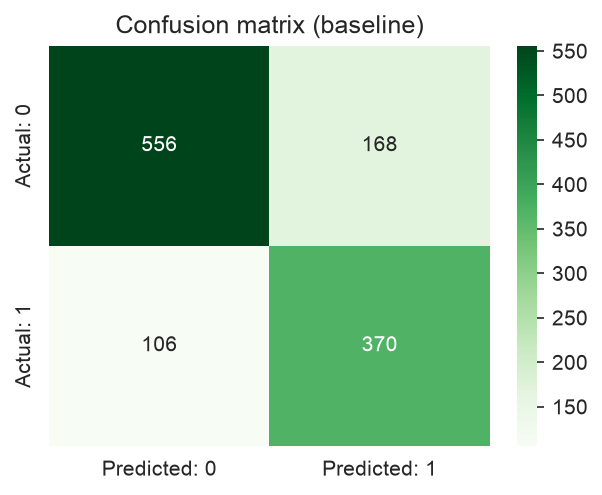

              precision    recall  f1-score   support

           0      0.840     0.768     0.802       724
           1      0.688     0.777     0.730       476

    accuracy                          0.772      1200
   macro avg      0.764     0.773     0.766      1200
weighted avg      0.780     0.772     0.774      1200



In [8]:
# 혼동 행렬 (행=실제, 열=예측) — 본문 3.3절 그림의 출처
proba = baseline.predict_proba(X_test)[:, 1]
pred = (proba > 0.5).astype(int)
cm = confusion_matrix(y_test, pred)
cm_df = pd.DataFrame(cm, index=["Actual: 0", "Actual: 1"], columns=["Predicted: 0", "Predicted: 1"])
plt.figure(figsize=(4.2, 3.4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion matrix (baseline)")
plt.tight_layout(); plt.show()
print(classification_report(y_test, pred, digits=3))

### 2.3. (선택) Optuna로 하이퍼파라미터 최적화

해석용 모델이라 화려한 튜닝이 꼭 필요하진 않지만, **Optuna** 로 교차검증 AUC를 목적함수 삼아
하이퍼파라미터를 좀 더 깊이 탐색해 볼 수 있습니다. 샘플러 시드를 고정해 재현 가능하게 두고,
탐색 횟수(`n_trials`)는 실습용으로 작게 잡습니다.

찾은 최적 파라미터로 다시 학습한 모델(clf)을 베이스라인과 비교합니다. 이후 SHAP 해석에는 이 모델을 씁니다.
이 단계를 건너뛴다면 다음 절의 SHAP 계산에서 `clf = baseline` 한 줄만 실행해 베이스라인 모델을
그대로 넘겨주면 됩니다.

In [9]:
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import StratifiedKFold, cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = dict(
        num_leaves=trial.suggest_int("num_leaves", 8, 64),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        n_estimators=300,
        min_child_samples=trial.suggest_int("min_child_samples", 10, 120),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        subsample_freq=1,
        class_weight="balanced", random_state=314, n_jobs=4, verbose=-1,
    )
    model = lgb.LGBMClassifier(**params)
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=314)
    return cross_val_score(model, X_train, y_train, cv=skf, scoring="roc_auc").mean()

study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=314))
study.optimize(objective, n_trials=25, show_progress_bar=False)
print(f"best CV AUC = {study.best_value:.4f}")
study.best_params

best CV AUC = 0.8587


{'num_leaves': 8,
 'learning_rate': 0.016826104963074903,
 'min_child_samples': 119,
 'colsample_bytree': 0.6998025760772738,
 'subsample': 0.7532175834062731}

In [10]:
# 최적 파라미터로 재학습 후 베이스라인과 비교 — 이 clf 를 SHAP 해석에 쓴다
best_params = {**study.best_params, "n_estimators": 1000, "subsample_freq": 1,
               "class_weight": "balanced", "random_state": 314, "n_jobs": 4,
               "metric": "None", "verbose": -1}
clf = lgb.LGBMClassifier(**best_params)
clf.fit(X_train, y_train, eval_set=[(X_test, y_test)], eval_metric="auc",
        callbacks=[lgb.early_stopping(10, verbose=False)])
tuned_acc, tuned_auc = report(clf, "optuna-tuned")

pd.DataFrame({"accuracy": [base_acc, tuned_acc], "AUC": [base_auc, tuned_auc]},
             index=["baseline", "optuna-tuned"]).round(4)

[optuna-tuned]  accuracy=0.7767  AUC=0.8539  best_iter=185


,accuracy,AUC
baseline,0.77,0.85
optuna-tuned,0.78,0.85


해석용 모델에서는 1~2%의 정확도 차이가 결론을 바꾸지 않는 경우가 많습니다. 튜닝은
"조금 더 나은 모델로 기여도를 본다" 정도의 의미이고, 이제 이 모델로 SHAP을 그립니다.

### 2.4. SHAP summary plot & dependence plot

SHAP summary plot은 한 장에 많은 걸 담습니다.
- **가로축(SHAP value)** : 오른쪽일수록 그 행동이 **잔존 예측을 끌어올림**
- **색** : 그 피처 값의 크기 (빨강=높음, 파랑=낮음)

예를 들어 `page_view_content_detail`가 빨강(많이 봄)일수록 오른쪽(잔존↑)에 모이면, "콘텐츠를 많이 볼수록
잔존이 올라간다"는 관계를 읽을 수 있습니다.

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


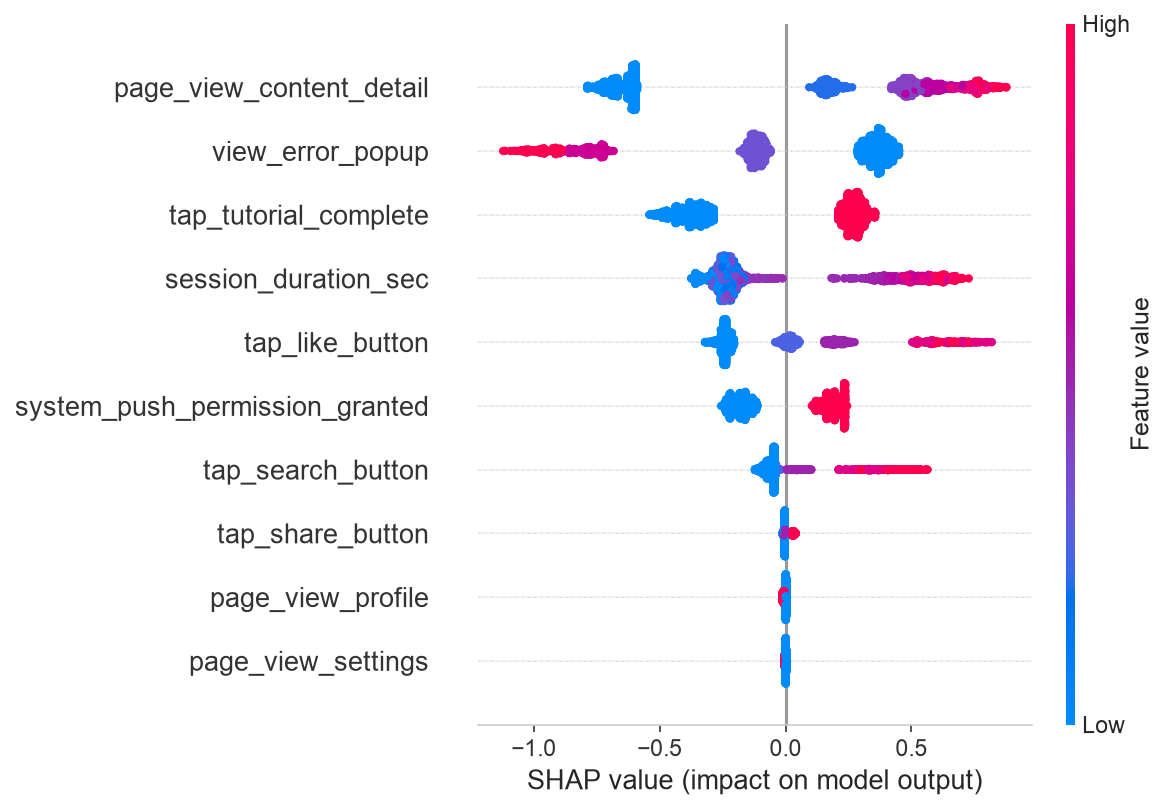

In [11]:
import shap
shap.initjs()

explainer = shap.TreeExplainer(clf.booster_)
X_shap = X_train.sample(frac=0.3, random_state=314)
shap_values = explainer.shap_values(X_shap)
# 이진 분류에서 리스트로 반환되면 양성 클래스 기준 사용
sv = shap_values[1] if isinstance(shap_values, list) else shap_values
shap.summary_plot(sv, X_shap, show=True)

### SHAP dependence plot — 임계값(아하 모먼트) 탐색

SHAP은 데이터 row 단위로 계산되므로, **피처 값에 따라 기여도가 어떻게 변하는지** 곡선으로 볼 수
있습니다. 값이 커지다가 기여도가 **양수로 꺾이는 임계점**이 보이면, 그게 곧 "아하 모먼트"
후보입니다. (색은 `page_view_content_detail`와의 상호작용)

이어서 dependence plot으로 피처 값에 따라 기여도가 어떻게 변하는지, 임계점이 있는지 봅니다.

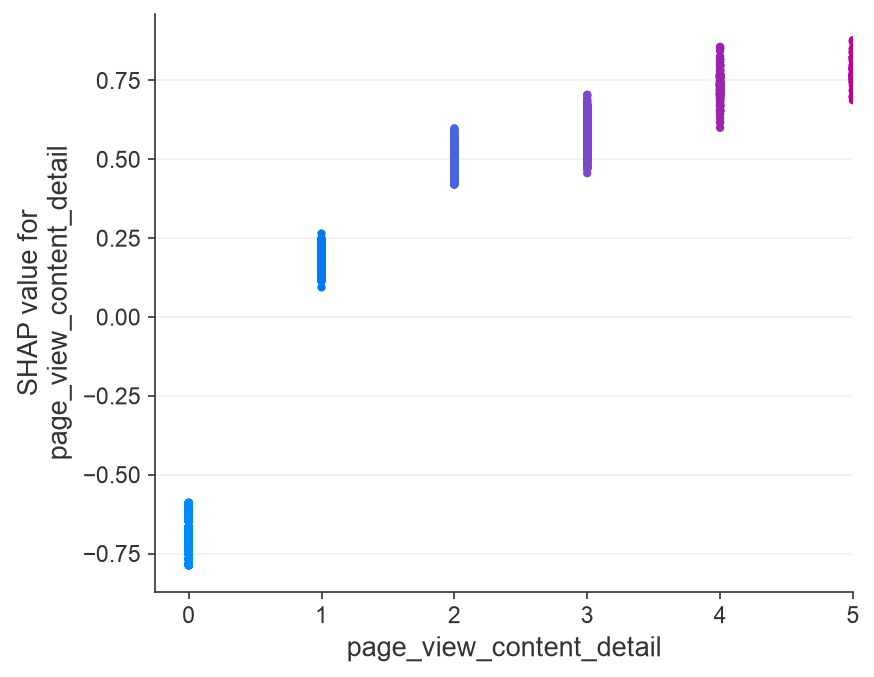

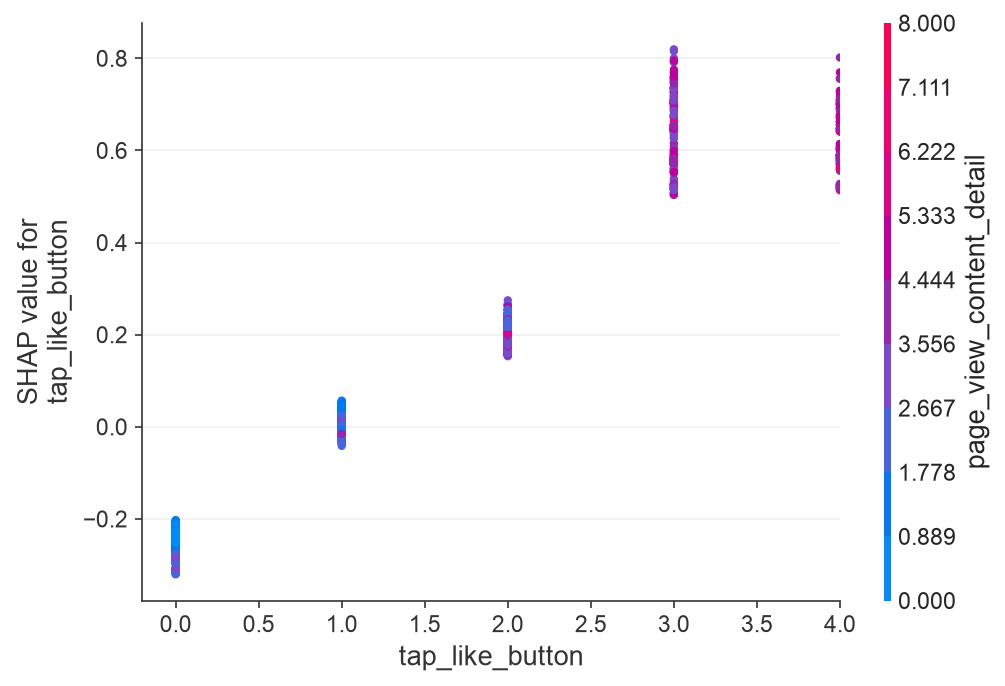

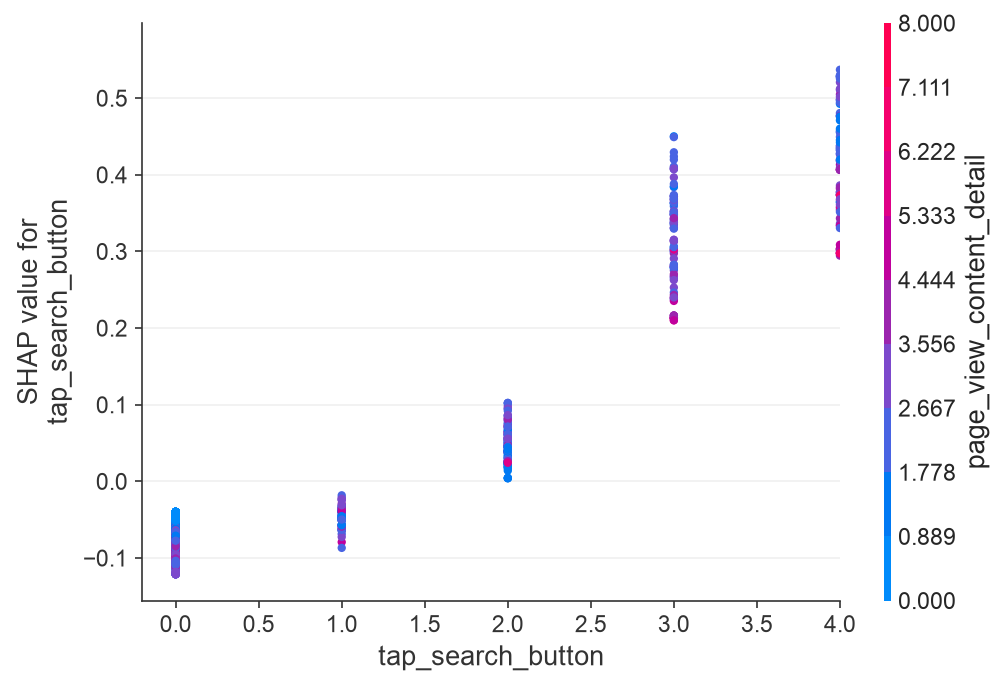

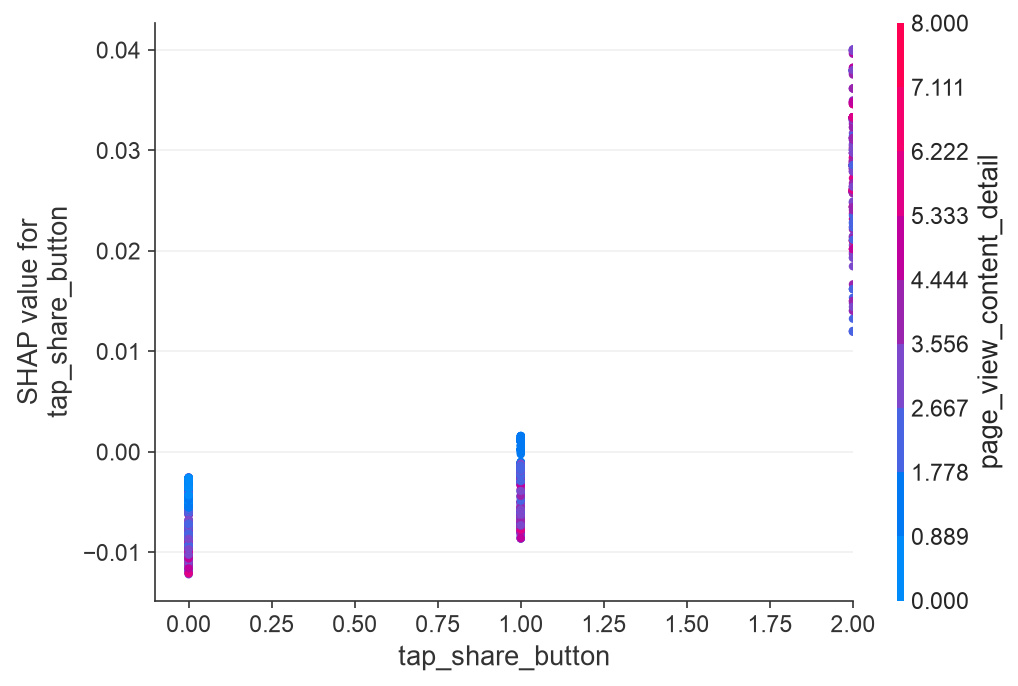

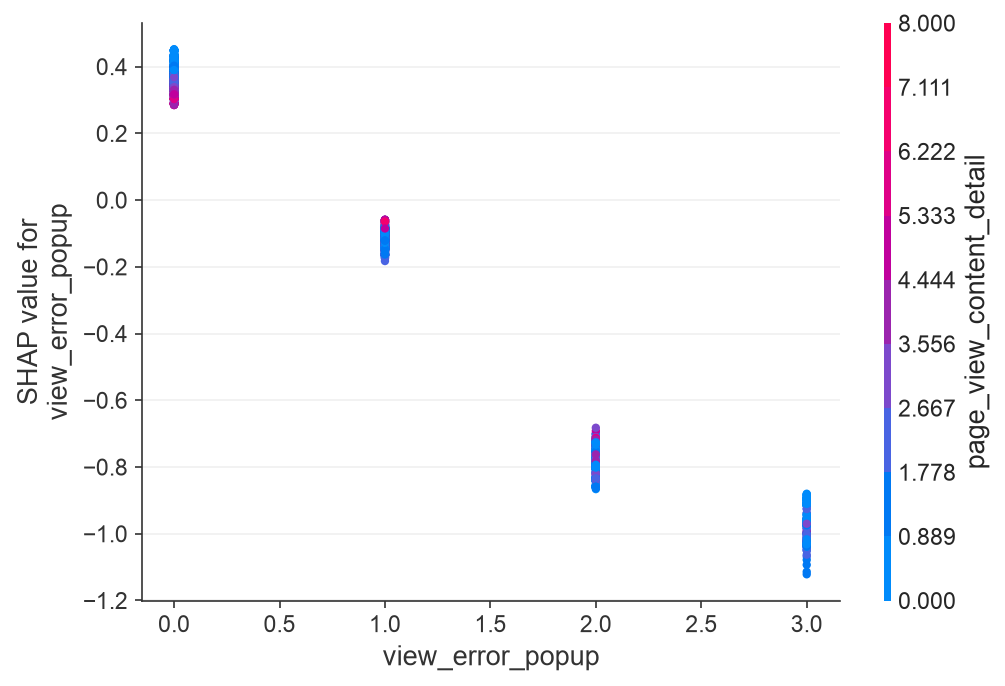

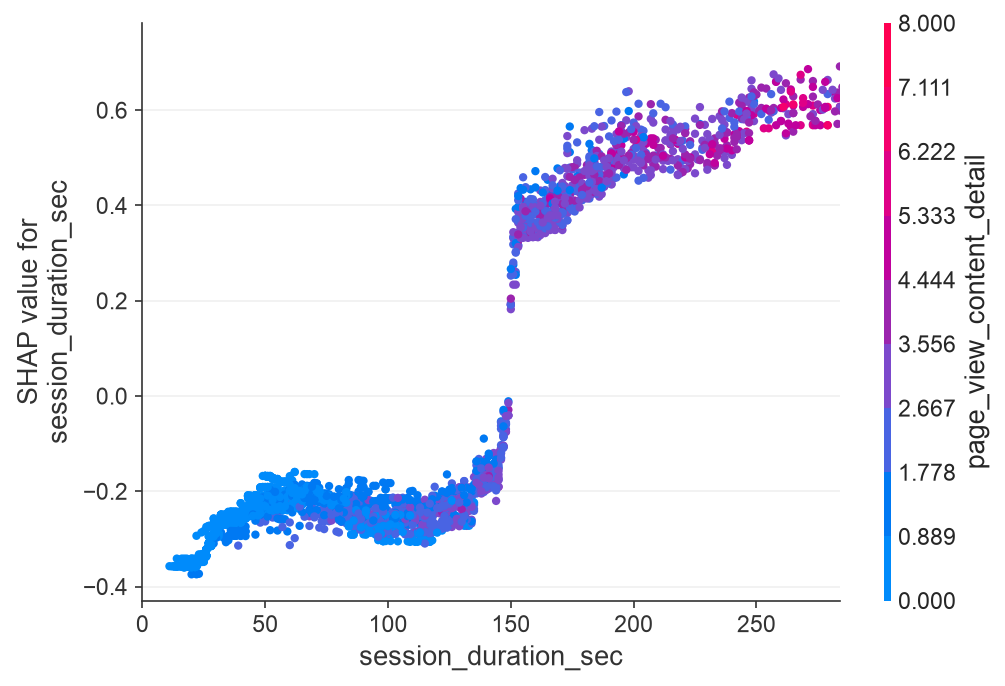

In [12]:
NUMERIC = ["page_view_content_detail", "tap_like_button", "tap_search_button",
           "tap_share_button", "view_error_popup", "session_duration_sec"]

for name in NUMERIC:
    xmax = X_shap[name].quantile(0.95) or max(X_shap[name].max(), 1)   # 상위 5% 극단값은 잘라서 본다
    shap.dependence_plot(name, sv, X_shap, interaction_index="page_view_content_detail",
                         xmin=0, xmax=xmax, show=True)

`session_duration_sec`는 약 **150초** 부근에서, `tap_like_button`는 **3회** 부근에서 SHAP 값이
양수로 꺾이는 게 보입니다. "첫 세션 2분 30초 이상 / 좋아요 3회 이상"처럼, 막연한 행동을
**구체적인 선행지표 목표**로 바꿔 제안할 수 있습니다.

---
## 실습 3. Sankey Diagram으로 유저의 흐름 진단하기

지금까지는 행동을 **개별 이벤트**로 봤습니다. 마지막은 **흐름(flow)** 입니다. 설치 직후 유저가
거치는 화면·행동을 순서대로 잇고, 각 전이를 지나간 유저들의 **D7 잔존율로 색칠**합니다.
그러면 *같은 갈림길에서 어느 쪽으로 가면 잔존이 떨어지는지*가 색으로 드러납니다.
본문 4절의 그림7과 8이 이 실습의 결과입니다.

### 3.1. 스텝 전이 쿼리

설치 후 1시간 이내 이벤트를 순서대로 늘어놓고(연속 중복 제거), 스텝 N → N+1 전이를 만들어
전이별 유저 수와 D7 잔존율을 집계합니다. 스텝 위치마다 상위 `TOP_K` 이벤트만 남기고 나머지는
`ETC`로 묶어 그림을 읽기 쉽게 합니다. (쿼리는 `sql/sankey_transitions.sql` 에도 있습니다.)

먼저 설치 후 1시간 안의 이벤트를 유저별 스텝 순서로 정리한 뷰를 만듭니다.

In [13]:
MAX_STEPS = 10    # 유저당 처음 N개 이벤트
TOP_K     = 6     # 스텝별 상위 K개 이벤트 (나머지는 ETC)
MIN_USERS = 20    # 링크로 그릴 최소 유저 수

con.execute(f"""
-- 설치 후 1시간 안의 이벤트를 순서대로 (연속 중복 제거) → 유저별 스텝 번호
CREATE OR REPLACE VIEW user_steps AS
  WITH session_events AS (
    SELECT i.user_id, e.event_name, e.event_timestamp,
           LAG(e.event_name) OVER (PARTITION BY i.user_id ORDER BY e.event_timestamp) AS prev_event
    FROM installs AS i
    JOIN event_log AS e
      ON i.user_id = e.user_id
     AND e.event_timestamp >= i.install_ts
     AND e.event_timestamp <= i.install_ts + INTERVAL 1 HOUR
  )
  SELECT user_id, event_name, event_timestamp,
         ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY event_timestamp) AS step_num
  FROM session_events
  WHERE prev_event IS NULL OR event_name != prev_event
  QUALIFY step_num <= {MAX_STEPS}
""")

스텝마다 상위 TOP_K 이벤트만 남기고 나머지는 ETC로 묶은 뒤, 전이별 유저 수와 D7 잔존율을 집계합니다.

In [14]:
sankey_query = f"""
WITH event_volume AS (   -- 스텝별 이벤트 빈도 순위
    SELECT step_num, event_name, COUNT(DISTINCT user_id) AS user_cnt,
           ROW_NUMBER() OVER (PARTITION BY step_num ORDER BY COUNT(DISTINCT user_id) DESC) AS rnk
    FROM user_steps
    GROUP BY 1, 2
),
steps_resolved AS (     -- 상위 K 밖 이벤트는 ETC 로 묶기
    SELECT s.user_id, s.step_num,
           CASE WHEN v.rnk <= {TOP_K} THEN s.event_name ELSE 'ETC' END AS event_name
    FROM user_steps AS s JOIN event_volume AS v USING (step_num, event_name)
),
transitions AS (        -- 스텝 N -> N+1 전이
    SELECT a.user_id, a.step_num AS from_step,
           CAST(a.step_num AS VARCHAR) || '-' || a.event_name AS source,
           CAST(b.step_num AS VARCHAR) || '-' || b.event_name AS target
    FROM steps_resolved AS a
    JOIN steps_resolved AS b ON a.user_id = b.user_id AND b.step_num = a.step_num + 1
)
SELECT t.from_step, t.source, t.target,
       COUNT(DISTINCT t.user_id) AS user_count,
       COUNT(DISTINCT CASE WHEN r.d7_retention_flag = 1 THEN t.user_id END) * 100.0
         / NULLIF(COUNT(DISTINCT t.user_id), 0) AS d7_retention
FROM transitions AS t LEFT JOIN d7_label AS r USING (user_id)
GROUP BY 1, 2, 3
HAVING COUNT(DISTINCT t.user_id) >= {MIN_USERS}
ORDER BY from_step, user_count DESC
"""
flows = con.query(sankey_query).to_df()
print(f"transitions: {flows.shape[0]} rows | "
      f"D7 retention range: {flows['d7_retention'].min():.1f}% ~ {flows['d7_retention'].max():.1f}%")
flows.head(12)

transitions: 84 rows | D7 retention range: 2.6% ~ 86.7%


,from_step,source,target,user_count,d7_retention
0,1,1-system_app_install,2-page_view_onboarding_step,12000,39.67
1,2,2-page_view_onboarding_step,3-tap_tutorial_complete,7034,52.63
2,2,2-page_view_onboarding_step,3-page_view_home,2809,14.95
3,2,2-page_view_onboarding_step,3-system_push_permission_granted,2157,29.62
4,3,3-tap_tutorial_complete,4-system_push_permission_granted,3813,61.84
5,3,3-tap_tutorial_complete,4-page_view_home,3221,41.73
6,3,3-system_push_permission_granted,4-page_view_home,2157,29.62
7,3,3-page_view_home,4-page_view_content_detail,1196,27.59
8,3,3-page_view_home,4-page_view_settings,834,5.52
9,3,3-page_view_home,4-page_view_profile,779,5.65


### 3.2. 잔존율로 색칠한 Sankey

링크 **두께 = 유저 수**, 링크 **색 = D7 잔존율**(빨강=낮음 → 초록=높음)입니다. 같은 노드에서
갈라지는 링크의 색을 비교하면 어느 분기가 잔존을 떨어뜨리는지 보입니다. 노드 색은 들어오는
링크의 유저 수 가중 평균 잔존율로 칠합니다.

In [15]:
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "notebook_connected"   # plotly.js 를 CDN 에서 불러와 노트북 파일을 가볍게 유지

labels = list(pd.unique(flows[["source", "target"]].values.ravel()))
label_to_idx = {lab: i for i, lab in enumerate(labels)}
flows["source_idx"] = flows["source"].map(label_to_idx)
flows["target_idx"] = flows["target"].map(label_to_idx)

# 노드 잔존율 = 들어오는 링크의 유저수 가중 평균 (들어오는 링크가 없는 시작 노드는 나가는 링크로)
node_ret = {}
for lab in labels:
    inc = flows[flows["target"] == lab]
    use = inc if len(inc) else flows[flows["source"] == lab]
    node_ret[lab] = np.average(use["d7_retention"], weights=use["user_count"]) if len(use) else 0.0

# 잔존율 → 색: 하위 10% 는 회색, 상위 10% 는 초록, 그 사이는 호박색을 거쳐 보간 (책 공통 팔레트)
ret_min, ret_max = flows["d7_retention"].quantile(0.1), flows["d7_retention"].quantile(0.9)
def ret_to_rgba(ret, alpha=0.55):
    t = np.clip((ret - ret_min) / max(ret_max - ret_min, 1), 0, 1)
    if t < 0.5:  # gray -> amber
        s = t * 2; r, g, b = 201 + s*16, 197 - s*78, 192 - s*186
    else:        # amber -> green
        s = (t - 0.5) * 2; r, g, b = 217 - s*186, 119 + s*38, 6 + s*114
    return f"rgba({int(r)},{int(g)},{int(b)},{alpha})"

색을 입힌 링크와 노드로 Sankey를 그립니다.

In [16]:
link_colors = [ret_to_rgba(r) for r in flows["d7_retention"]]
node_colors = [ret_to_rgba(node_ret[l], 0.85) for l in labels]
node_disp = [f"{l}  ({node_ret[l]:.0f}%)" for l in labels]
link_hover = [f"{r.user_count:,} users | D7 retention: {r.d7_retention:.1f}%" for r in flows.itertuples()]

fig = go.Figure(go.Sankey(
    arrangement="snap",
    node=dict(pad=28, thickness=20, line=dict(color="#333", width=0.6),
              label=node_disp, color=node_colors, hovertemplate="%{label}<extra></extra>"),
    link=dict(source=flows["source_idx"], target=flows["target_idx"],
              value=flows["user_count"], color=link_colors, customdata=link_hover,
              hovertemplate="%{source.label} → %{target.label}<br>%{customdata}<extra></extra>"),
))
fig.update_layout(title="Install-session flow → D7 retention (link color = retention rate)",
                  font=dict(size=12), width=1800, height=720, paper_bgcolor="white")
fig.show()

### 잔존이 갈리는 분기 진단

색만으로도 보이지만, 같은 출발점에서 갈라지는 전이를 잔존율로 직접 비교하면 더 분명합니다.

그림을 숫자로 다시 확인합니다. 같은 지점에서 갈라지는 전이 가운데 잔존율 차이가 큰 갈림길, 그리고 잔존율 상·하위 전이를 뽑아 봅니다.

In [17]:
# 같은 source 에서 갈라지는 전이들 — 잔존율 차이가 큰 분기(갈림길)부터
flows["ret_gap_at_source"] = flows.groupby("source")["d7_retention"].transform(lambda s: s.max() - s.min())
branches = (flows[flows["ret_gap_at_source"] > 15]
            .sort_values(["ret_gap_at_source", "source", "d7_retention"], ascending=[False, True, False]))
display(branches[["from_step", "source", "target", "user_count", "d7_retention"]].head(14).round(1))

# 잔존율 상·하위 전이 (유저 50명 이상)
big = flows[flows["user_count"] >= 50]
for title, sub in [("TOP", big.nlargest(8, "d7_retention")), ("BOTTOM", big.nsmallest(8, "d7_retention"))]:
    print("=" * 70, f"\n{title} transitions by D7 retention (min 50 users)\n", "=" * 70)
    for r in sub.itertuples():
        print(f"  {r.source:>28s} -> {r.target:<26s}  {r.user_count:>5,}u  {r.d7_retention:5.1f}%")

,from_step,source,target,user_count,d7_retention
19,5,5-page_view_home,6-page_view_content_detail,2834,74.60
24,5,5-page_view_home,6-page_view_profile,475,24.80
23,5,5-page_view_home,6-page_view_settings,504,24.80
62,8,8-tap_like_button,9-page_view_content_detail,415,74.50
68,8,8-tap_like_button,9-tap_search_button,97,74.20
63,8,8-tap_like_button,9-tap_share_button,310,71.30
65,8,8-tap_like_button,9-view_error_popup,117,29.90
50,7,7-tap_like_button,8-tap_share_button,737,79.60
48,7,7-tap_like_button,8-page_view_content_detail,1258,78.70
57,7,7-tap_like_button,8-tap_search_button,103,72.80


TOP transitions by D7 retention (min 50 users)
             9-tap_like_button -> 10-page_view_content_detail    641u   86.7%
             9-tap_like_button -> 10-tap_share_button           428u   83.9%
    9-page_view_content_detail -> 10-tap_like_button            803u   83.6%
            8-tap_share_button -> 9-page_view_content_detail    677u   82.1%
            9-tap_share_button -> 10-page_view_content_detail    329u   80.9%
    8-page_view_content_detail -> 9-tap_like_button           1,450u   80.3%
             7-tap_like_button -> 8-tap_share_button            737u   79.6%
             7-tap_like_button -> 8-page_view_content_detail  1,258u   78.7%
BOTTOM transitions by D7 retention (min 50 users)
           4-page_view_profile -> 5-view_error_popup            547u    2.6%
          4-page_view_settings -> 5-view_error_popup            535u    3.6%
              3-page_view_home -> 4-page_view_settings          834u    5.5%
              3-page_view_home -> 4-page_view_profile 

---
## 정리 — 세 방법이 공통으로 가리키는 행동

세 실습의 결과를 나란히 놓아 보겠습니다.

| 방법 | 상위로 올라온 행동 |
| --- | --- |
| EDA 비교 (`share_diff`, `avg_event_count`) | 튜토리얼 완료 · 콘텐츠 상세 조회 · 좋아요 · (횟수로) 검색 |
| SHAP (summary · dependence) | 콘텐츠 상세 조회 · 에러 팝업(음의 기여) · 세션 체류 시간 약 150초 · 좋아요 약 3회 |
| Sankey (`branches`) | 온보딩을 건너뛰고 홈으로 가는 갈림길 · 콘텐츠 상세 조회로의 회복 · 좋아요 → 콘텐츠·공유 전이 |

콘텐츠 상세 조회와 좋아요는 세 방법이 모두 가리켰고, 튜토리얼 완료는 EDA와 Sankey가, 세션 체류 시간은 SHAP만
짚었습니다. 가정이 다른 방법이 겹쳐 지목한 콘텐츠 상세 조회와 좋아요 3회를 실험 우선순위 첫째로 두고, 한 방법에서만
나온 세션 체류 시간은 그다음에 두는 식으로 가설 목록을 정리하면 됩니다. 다만 여기서 찾은 것은 어디까지나
상관관계입니다 — 겹친 행동으로 A/B 실험을 설계한 뒤(3장), 개입 후에는 가드레일 지표를 함께 모니터링합니다.
